# Multi-Output Gaussian Processes — LMC, ICM, OILMM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/multioutput_gp.ipynb)

When you have **several correlated outputs** sharing a common input, three multi-output GP constructions cover the regimes you actually need:

| Kernel | Idea | Cost | When to use |
|--------|------|------|-------------|
| `LMCKernel` | Each output = linear combination of $Q$ independent latent GPs, each with its own kernel. | Sum of $Q$ Kroneckers $\sum_q B_q \otimes K_q$. | Outputs share *some* structure but have heterogeneous lengthscales. |
| `ICMKernel` | Single shared latent kernel; outputs differ only by mixing coefficients. | One Kronecker $B \otimes K$ — fastest. | Outputs are smooth versions of the same underlying field. |
| `OILMMKernel` | Orthogonal mixing — observations project to $Q$ *independent* latent GP problems. | $Q$ scalar GP solves. | Many outputs, few latents. |

`pyrox.gp` exposes all three as plain `equinox.Module` kernels that return structured `lineax` operators (Kronecker, sum-of-Kroneckers, block-diagonal).  Downstream `gaussx` solvers exploit that structure automatically — no need to materialise the full $(P\!N) \times (P\!N)$ Gram matrix.

This notebook walks through:

1. **LMC on two coupled outputs** — share information across outputs to predict where one is missing.
2. **ICM as a single-Kronecker special case** — show the structure tag pyrox emits so solvers can pick the fast path.
3. **OILMM project / back-project workflow** — many outputs, few latents, $Q$ independent scalar GPs.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import jax.random as jr
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    is_block_diagonal,
    is_kronecker,
    log_marginal_likelihood,
    oilmm_back_project,
    oilmm_project,
)

from pyrox.gp import RBF, ICMKernel, LMCKernel, OILMMKernel


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,gaussx,pyrox,lineax,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
gaussx    : 0.0.10
pyrox     : 0.0.6
lineax    : 0.1.0
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. LMC — borrowing strength across outputs

Two outputs share a common latent function $g(x)$ but observe it through different mixing weights and add their own noise:

$$
y_1(x) = w_{1,1} g_1(x) + w_{1,2} g_2(x) + \varepsilon_1, \qquad
y_2(x) = w_{2,1} g_1(x) + w_{2,2} g_2(x) + \varepsilon_2.
$$

We hide a chunk of $y_1$ and ask the LMC posterior to fill it in **using $y_2$**.  An independent-output GP cannot do this; an LMC with $Q = 2$ latents can.

In [4]:
n = 60
key = jr.PRNGKey(0)
key_g1, key_g2, key_eps1, key_eps2 = jr.split(key, 4)
x = jnp.linspace(-3.0, 3.0, n).reshape(-1, 1)

# Two latent GPs with *different* lengthscales — one short, one long. The
# LMC model below uses these same lengthscales, so the data is in-class.
true_kernel_short = RBF(init_variance=1.0, init_lengthscale=0.6)
true_kernel_long = RBF(init_variance=0.5, init_lengthscale=2.0)
K_short = true_kernel_short(x, x) + 1e-8 * jnp.eye(n)
K_long = true_kernel_long(x, x) + 1e-8 * jnp.eye(n)
L_short = jnp.linalg.cholesky(K_short)
L_long = jnp.linalg.cholesky(K_long)
g1 = L_short @ jr.normal(key_g1, (n,))  # short-lengthscale latent
g2 = L_long @ jr.normal(key_g2, (n,))  # long-lengthscale latent

W = jnp.array([[1.0, 0.4], [0.3, 1.1]])
noise_std = 0.05
y1_full = W[0, 0] * g1 + W[0, 1] * g2 + noise_std * jr.normal(key_eps1, (n,))
y2_full = W[1, 0] * g1 + W[1, 1] * g2 + noise_std * jr.normal(key_eps2, (n,))

# Hide the centre of y1 — the LMC must reconstruct it from y2 and the LMC structure.
mask_y1 = (x[:, 0] > -1.0) & (x[:, 0] < 1.0)
y1 = y1_full.at[mask_y1].set(jnp.nan)
y2 = y2_full

Build an LMC kernel with two latent processes and compute the **dense** $(2N) \times (2N)$ Gram for the joint GP.  We do the mask handling by stripping the missing entries from `vec(Y)`; the LMC posterior at those held-out indices is what we want.

In [5]:
# Two latent kernels (give them different lengthscales so LMC ≠ ICM).
lmc = LMCKernel(
    kernels=(
        RBF(pyrox_name="rbf_q0", init_variance=1.0, init_lengthscale=0.6),
        RBF(pyrox_name="rbf_q1", init_variance=0.5, init_lengthscale=2.0),
    ),
    mixing=W,
)

K_full = lmc.full_covariance(x)  # (2N, 2N) — vec ordering: y1 then y2
print(f"LMC Gram shape: {K_full.shape}  (P=2 outputs × N={n} inputs)")

# Build the joint observation vector and apply the missing-entry mask.
# vec(Y) ordering: lmc.full_covariance stacks rows as [output 0 inputs..., output 1 inputs...].
y_vec = jnp.concatenate([y1, y2])
mask_vec = jnp.concatenate([~mask_y1, jnp.ones_like(mask_y1, dtype=bool)])

y_obs = y_vec[mask_vec]
K_oo = K_full[mask_vec][:, mask_vec]  # observed-observed
K_uo = K_full[~mask_vec][:, mask_vec]  # unobserved-observed (the gap entries of y1)
K_uu = K_full[~mask_vec][:, ~mask_vec]

noise_var = noise_std**2
A = K_oo + noise_var * jnp.eye(K_oo.shape[0])
alpha = jnp.linalg.solve(A, y_obs)
mean_gap = K_uo @ alpha
var_gap = jnp.diag(K_uu - K_uo @ jnp.linalg.solve(A, K_uo.T))

LMC Gram shape: (120, 120)  (P=2 outputs × N=60 inputs)


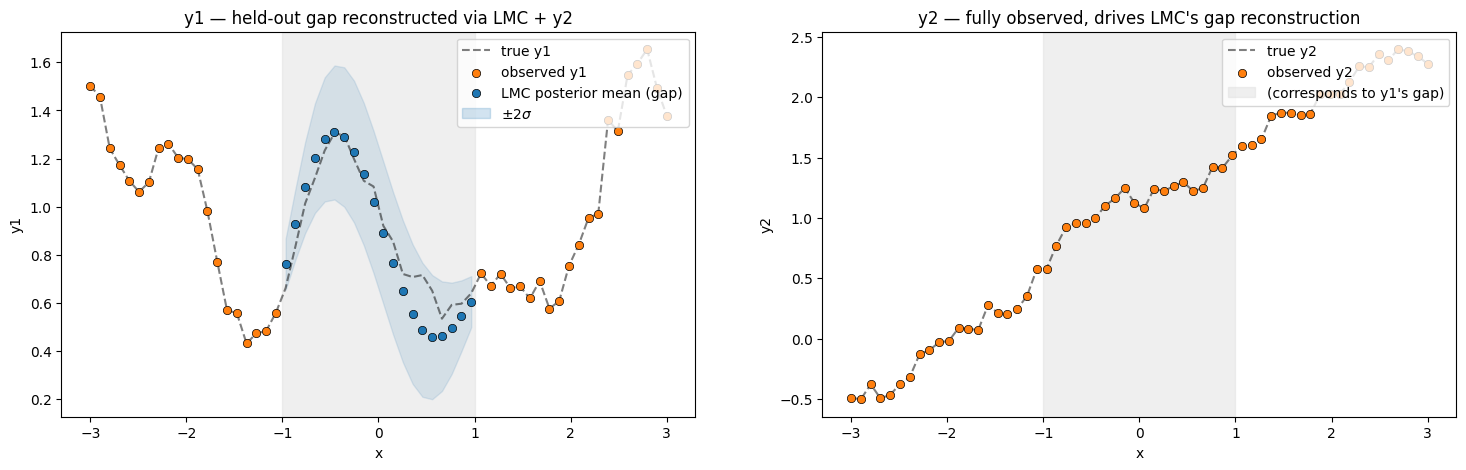

LMC RMSE on held-out y1 gap: 0.0958


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# y1 — has the gap.
axes[0].plot(x[:, 0], y1_full, "k--", alpha=0.5, label="true y1")
axes[0].scatter(
    x[~mask_y1, 0], y1_full[~mask_y1], c="C1", edgecolors="k", linewidths=0.5,
    zorder=5, label="observed y1",
)
axes[0].scatter(
    x[mask_y1, 0], mean_gap, c="C0", edgecolors="k", linewidths=0.5,
    zorder=5, label="LMC posterior mean (gap)",
)
axes[0].fill_between(
    x[mask_y1, 0],
    mean_gap - 2 * jnp.sqrt(var_gap),
    mean_gap + 2 * jnp.sqrt(var_gap),
    color="C0",
    alpha=0.2,
    label=r"$\pm 2\sigma$",
)
axes[0].axvspan(-1.0, 1.0, color="0.85", alpha=0.4)
axes[0].set_title("y1 — held-out gap reconstructed via LMC + y2")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y1")
axes[0].legend(loc="upper right")

# y2 — fully observed; show LMC sees it.
axes[1].plot(x[:, 0], y2_full, "k--", alpha=0.5, label="true y2")
axes[1].scatter(
    x[:, 0], y2, c="C1", edgecolors="k", linewidths=0.5, zorder=5, label="observed y2"
)
axes[1].axvspan(-1.0, 1.0, color="0.85", alpha=0.4, label="(corresponds to y1's gap)")
axes[1].set_title("y2 — fully observed, drives LMC's gap reconstruction")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y2")
axes[1].legend(loc="upper right")
plt.show()

rmse = float(jnp.sqrt(jnp.mean((mean_gap - y1_full[mask_y1]) ** 2)))
print(f"LMC RMSE on held-out y1 gap: {rmse:.4f}")

The LMC posterior fills the gap in $y_1$ near the truth even though no $y_1$ values were observed in $[-1, 1]$ — the cross-output covariance routes information from $y_2$ through the latent processes back into $y_1$.

## 2. ICM — the single-Kronecker special case

`ICMKernel` is the LMC restriction to a **single** shared latent kernel.  The output covariance factorises exactly into one Kronecker product $B \otimes K$, where $B = W W^\top + \mathrm{diag}(\kappa)$.

`pyrox.gp.ICMKernel.cross_covariance_operator` returns a `lineax` operator with the **Kronecker tag** set, so any downstream `gaussx` log-marginal / solve routine can pick the Kronecker-exact path automatically.

In [7]:
icm = ICMKernel(
    kernel=RBF(init_variance=1.0, init_lengthscale=0.6),
    mixing=jnp.array([[1.0, 0.5], [0.5, 1.2], [0.2, 0.9]]),  # P=3 outputs, Q=2 latents
    kappa=jnp.array([0.05, 0.05, 0.05]),  # per-output extra diagonal variance
)

K_op = icm.cross_covariance_operator(x, x)
print(f"ICM operator: {type(K_op).__name__}")
print(f"is_kronecker tag set:    {is_kronecker(K_op)}")
print(f"Operator dense shape:    {K_op.as_matrix().shape}")
print(f"Coregionalization B:\n{icm.coregionalization_matrix()}")

ICM operator: Kronecker
is_kronecker tag set:    True
Operator dense shape:    (180, 180)
Coregionalization B:
[[1.3  1.1  0.65]
 [1.1  1.74 1.18]
 [0.65 1.18 0.9 ]]


`is_kronecker(K_op) → True` is the load-bearing fact: it tells `gaussx` that a single Cholesky on the $P \times P$ block factor and a single Cholesky on the $N \times N$ kernel factor are enough — the dense $(PN) \times (PN)$ system is *never* materialised internally even though `as_matrix()` exists for inspection.

## 3. OILMM — project, run scalar GPs, back-project

`OILMMKernel` requires the mixing matrix $W$ to be **semi-orthogonal** ($W^\top W = I$).  That orthogonality lets you *project* multi-output observations $Y \in \mathbb{R}^{N \times P}$ into latent space $\widetilde Y \in \mathbb{R}^{N \times Q}$, run $Q$ **independent** scalar GP problems, then back-project predictive means and variances into the original $P$-dim output space.

The result: you turn one big $(PN) \times (PN)$ multi-output solve into $Q$ small $N \times N$ scalar GP solves.

In [8]:
P = 4
Q = 2
n_in = 80
key_y, key_w = jr.split(jr.PRNGKey(7), 2)
x_oi = jnp.linspace(-3.0, 3.0, n_in).reshape(-1, 1)

# Generate a random orthogonal mixing matrix via QR.
W_random = jr.normal(key_w, (P, Q))
W_oi, _ = jnp.linalg.qr(W_random)  # (P, Q) with W^T W = I_Q

# Two ground-truth latent GPs (well-separated lengthscales).
true_kernels = [
    RBF(init_variance=1.0, init_lengthscale=0.5),
    RBF(init_variance=0.6, init_lengthscale=2.0),
]
G = jnp.stack(
    [
        jnp.linalg.cholesky(k(x_oi, x_oi) + 1e-8 * jnp.eye(n_in))
        @ jr.normal(jr.fold_in(key_y, q), (n_in,))
        for q, k in enumerate(true_kernels)
    ],
    axis=-1,
)  # (N, Q)

noise_var_per_output = 0.04 * jnp.ones(P)
Y = G @ W_oi.T + jnp.sqrt(noise_var_per_output) * jr.normal(
    jr.fold_in(key_y, 99), (n_in, P)
)

Project the $P$-dim observations into the $Q$-dim latent space.

In [9]:
oilmm = OILMMKernel(
    kernels=(
        RBF(pyrox_name="rbf_lat0", init_variance=1.0, init_lengthscale=0.5),
        RBF(pyrox_name="rbf_lat1", init_variance=0.6, init_lengthscale=2.0),
    ),
    mixing=W_oi,
    check_orthogonal=True,
)

Y_lat, noise_lat = oilmm.project(Y, noise_var_per_output)
print(f"Y shape: {Y.shape}")
print(f"Y_latent shape: {Y_lat.shape}  (per-latent observations)")
print(f"per-latent noise variance: {np.asarray(noise_lat)}")

Y shape: (80, 4)
Y_latent shape: (80, 2)  (per-latent observations)
per-latent noise variance: [0.04 0.04]


Now run **two independent scalar GP regressions** — one per latent — using `gaussx.log_marginal_likelihood` for each, and do simple posterior-mean prediction in latent space before back-projecting.

In [10]:
def scalar_gp_predict(
    kernel: RBF,
    x_train: jax.Array,
    y_train: jax.Array,
    x_test: jax.Array,
    noise_var: float,
):
    K_xx = kernel(x_train, x_train) + noise_var * jnp.eye(x_train.shape[0])
    K_sx = kernel(x_test, x_train)
    K_ss_diag = kernel.diag(x_test)
    alpha = jnp.linalg.solve(K_xx, y_train)
    mean = K_sx @ alpha
    v = jnp.linalg.solve(K_xx, K_sx.T)
    var = K_ss_diag - jnp.sum(K_sx * v.T, axis=-1)
    return mean, var


x_test = jnp.linspace(-3.5, 3.5, 200).reshape(-1, 1)

f_means = []
f_vars = []
for q, kernel in enumerate(oilmm.independent_gps()):
    mean_q, var_q = scalar_gp_predict(
        kernel, x_oi, Y_lat[:, q], x_test, float(noise_lat[q])
    )
    f_means.append(mean_q)
    f_vars.append(var_q)
F_means = jnp.stack(f_means, axis=-1)  # (M, Q)
F_vars = jnp.stack(f_vars, axis=-1)

# Back-project to the original P=4 output space.
y_means, y_vars = oilmm.back_project(F_means, F_vars)
print(f"Back-projected predictive mean shape: {y_means.shape}  (M={x_test.shape[0]}, P={P})")

Back-projected predictive mean shape: (200, 4)  (M=200, P=4)


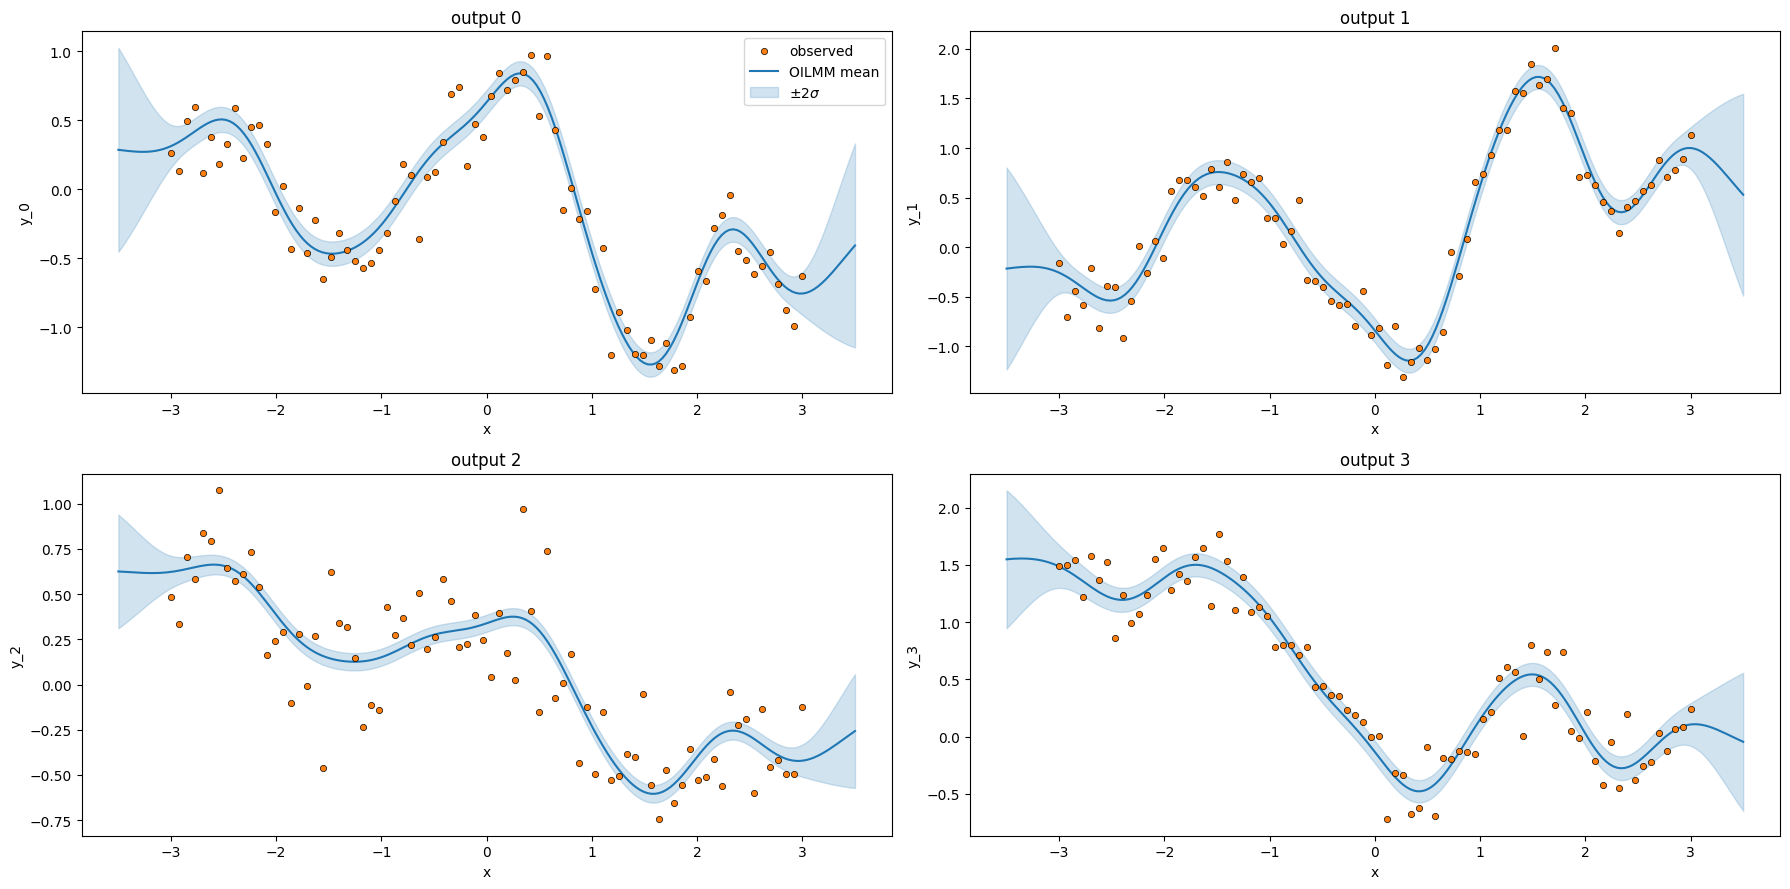

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 9))
for p, ax in enumerate(axes.ravel()):
    ax.scatter(
        x_oi[:, 0],
        Y[:, p],
        c="C1",
        edgecolors="k",
        linewidths=0.5,
        s=20,
        zorder=5,
        label="observed",
    )
    ax.plot(x_test[:, 0], y_means[:, p], color="C0", label="OILMM mean")
    ax.fill_between(
        x_test[:, 0],
        y_means[:, p] - 2 * jnp.sqrt(y_vars[:, p]),
        y_means[:, p] + 2 * jnp.sqrt(y_vars[:, p]),
        color="C0",
        alpha=0.2,
        label=r"$\pm 2\sigma$",
    )
    ax.set_title(f"output {p}")
    ax.set_xlabel("x")
    ax.set_ylabel(f"y_{p}")
    if p == 0:
        ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Two scalar GP fits — one per latent — produced predictive means and variances for **all four** outputs.  This is the OILMM win at scale: when $P$ is large but the cross-output structure is low-rank ($Q \ll P$), you pay $Q$ scalar GP costs instead of one monolithic $P$-output cost.

### Sanity check — `oilmm_project` round-trips

`oilmm_back_project` is the inverse of `oilmm_project` for the orthogonal mixing case.  Verify directly:

In [12]:
F_back, _ = oilmm.back_project(Y_lat, jnp.zeros_like(Y_lat))
F_recon = F_back  # back-projected mean
# Project Y_recon → latent and confirm it round-trips.
Y_lat_again, _ = oilmm.project(F_recon, 0.0)
err = float(jnp.max(jnp.abs(Y_lat - Y_lat_again)))
print(f"max round-trip error (project → back-project → project): {err:.2e}")

max round-trip error (project → back-project → project): 1.11e-15


## Takeaways

- **`LMCKernel`** — most expressive: $Q$ independent latent kernels combined by a free mixing matrix.  Use when outputs need different lengthscales but share structure.  Posterior fills missing entries in one output using observed entries of another.
- **`ICMKernel`** — single shared kernel + mixing matrix.  Returns a `lineax` operator carrying the **Kronecker tag**, which `gaussx` solvers exploit for an exact $\mathcal{O}(N^3 + P^3)$ solve instead of $\mathcal{O}((PN)^3)$.
- **`OILMMKernel`** — orthogonal mixing turns multi-output into $Q$ scalar GP problems.  Use `oilmm.project(Y, noise_var)` → run scalar GPs → `oilmm.back_project(means, vars)`.  Best when $P \gg Q$.